# Ejemplo práctico de poda de complejidad de costo mínimo

En este ejemplo veremos cómo usar Scikit-Learn para implementar el algoritmo de post-poda de complejidad de costo mínimo.

Comencemos importando las librerías requeridas:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

Y ahora leamos y visualicemos el set de datos:

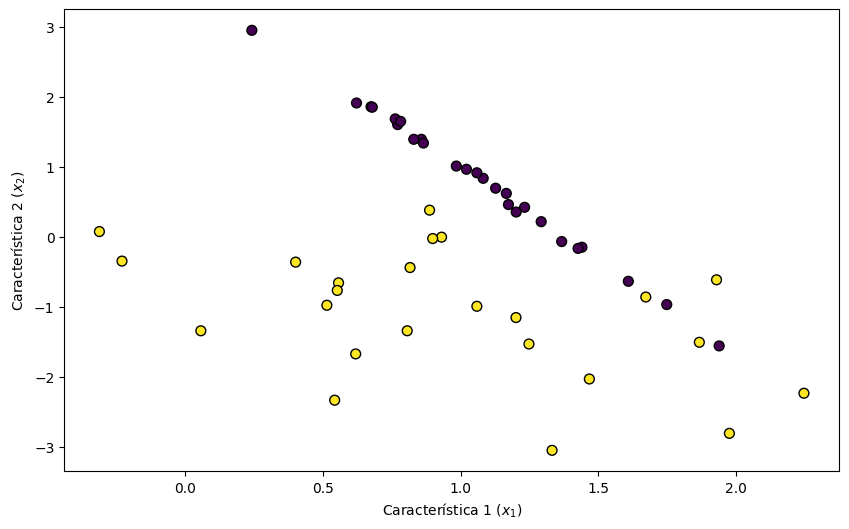

In [2]:
# Lectura
RUTA = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/28-2024-10-ArbolesDeDecision/data/'
datos = np.load(RUTA + 'XY.npz')
X = datos['X'] # Características
Y = datos['Y'] # Variable a predecir (categoría)

# Visualización
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=Y, edgecolor='k', s=50)
plt.xlabel('Característica 1 ($x_1$)')
plt.ylabel('Característica 2 ($x_2$)');

Comencemos subdividiendo el set de datos en entrenamiento (90%) y prueba (10%):

In [3]:
x_tr, x_ts, y_tr, y_ts = train_test_split(X, Y, test_size=0.1, random_state=42)

Y ahora vamos a entrenar el árbol de clasificación usando el set de entrenamiento. Intencionalmente haremos que este árbol tenga sobre-ajuste y para ello definiremos "max_depth" como "None":

Árbol original:
  Profundidad: 7
  Número de hojas: 8


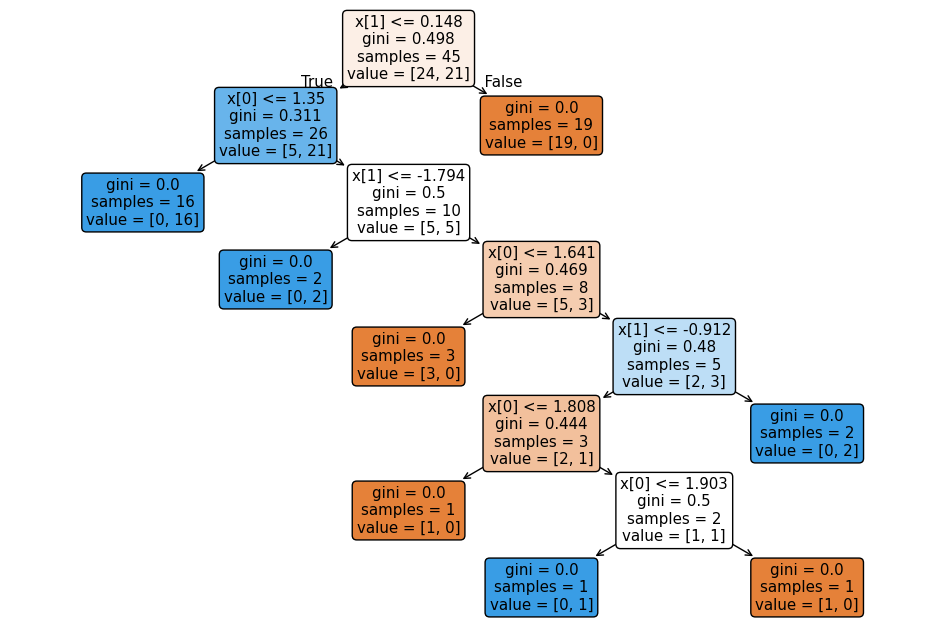

In [4]:
# Creación y entrenamiento del árbol
arbol = DecisionTreeClassifier(max_depth=None, random_state=42)
arbol.fit(x_tr, y_tr)

# Generar gráfico del árbol
plt.figure(figsize=(12, 8))
plot_tree(arbol, filled=True, rounded=True);

# Algunas características del árbol
print('Árbol original:')
print(f'  Profundidad: {arbol.get_depth()}')
print(f'  Número de hojas: {arbol.get_n_leaves()}')

Cuando se entrena el árbol, Scikit-Learn pone a disposición el método "cost_complexiy_pruning_path" que nos muestra diferentes valores de complejidad del árbol para diferentes valores de $\alpha$.

Recordemos que la complejidad se calcula como:

$$R_{\alpha}(T) = R(T) + \alpha \cdot T$$

donde:

- $R(T)$ es la sumatoria de la calidad de las hojas
- $\alpha$ es el factor de penalización (que indica qué tanta importancia le vamos a dar al tamaño del árbol)
- $T$ es el número de hojas

Obtengamos este "cost_complexiy_pruning_path" para el árbol que acabamos de entrenar:

In [5]:
path = arbol.cost_complexity_pruning_path(x_tr, y_tr)
ccp_alphas = path.ccp_alphas  # Alphas
impurities = path.impurities  # Costos (impurezas)

# Imprimir en pantalla los alphas y sus correspondientes impurezas (o costos)
print('Alpha            R(T)')
for alpha, r in zip(ccp_alphas, impurities):
    print(f'{alpha:.3f}            {r:.3f}')

Alpha            R(T)
0.000            0.000
0.015            0.030
0.024            0.053
0.029            0.111
0.068            0.179
0.318            0.498


La idea ahora es determinar cuál será el valor de $\alpha$ que resulta más adecuado para nuestro árbol. Es decir que:

> la idea es encontrar el $\alpha$ que genera el árbol **con el menor overfitting posible**

Y para ello:

1. Entrenaremos diferentes árboles usando los diferentes niveles de poda especificados en "ccp_alphas"
2. Validaremos cada árbol obtenido en (1) usando los sets de entrenamiento y prueba
3. Generaremos un gráfico que nos muestre, por cada valor de $\alpha$ el desempeño para entrenamiento y prueba
4. Escogeremos aquel valor de $\alpha$ que nos arroje el mínimo *overfitting* posible

Veamos cómo implementar estos cuatro pasos:

[0.         0.01481481 0.0237037  0.02888889 0.06837607 0.3182906 ]


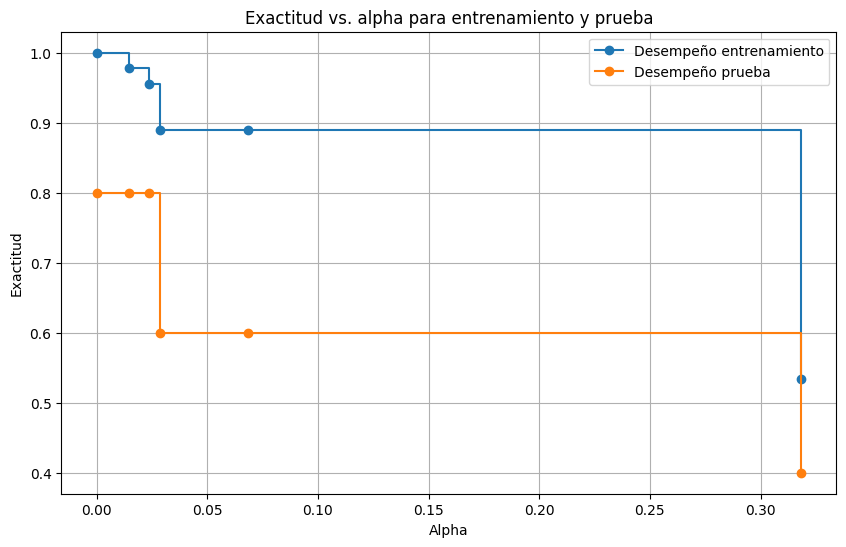

In [6]:
# 1. Entrenar diferentes árboles para diferentes valores de alpha (es decir con diferentes niveles de poda)
arboles = []
for alpha in ccp_alphas:
    arbol = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    arbol.fit(x_tr, y_tr)
    arboles.append(arbol)

# 2. Validar cada árbol con entrenamiento y prueba
scores_tr = [arbol.score(x_tr, y_tr) for arbol in arboles]
scores_ts = [arbol.score(x_ts, y_ts) for arbol in arboles]

# 3. Graficar desempeños vs. alpha 
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, scores_tr, marker='o', label="Desempeño entrenamiento", drawstyle="steps-post")
plt.plot(ccp_alphas, scores_ts, marker='o', label="Desempeño prueba", drawstyle="steps-post")
plt.xlabel("Alpha")
plt.ylabel("Exactitud")
plt.legend()
plt.title("Exactitud vs. alpha para entrenamiento y prueba")
plt.grid()

print(ccp_alphas)

El valor de alpha = 0.0237037 es el que genera un árbol con el menor overfitting. En este caso la exactitud de entrenamiento es de más o menos 95% vs. 80% para prueba.

Así que habiendo determinado el valor de $\alpha$ más adecuado, lo único que nos resta es entrenar el árbol final usando este valor y con el set de entrenamiento:

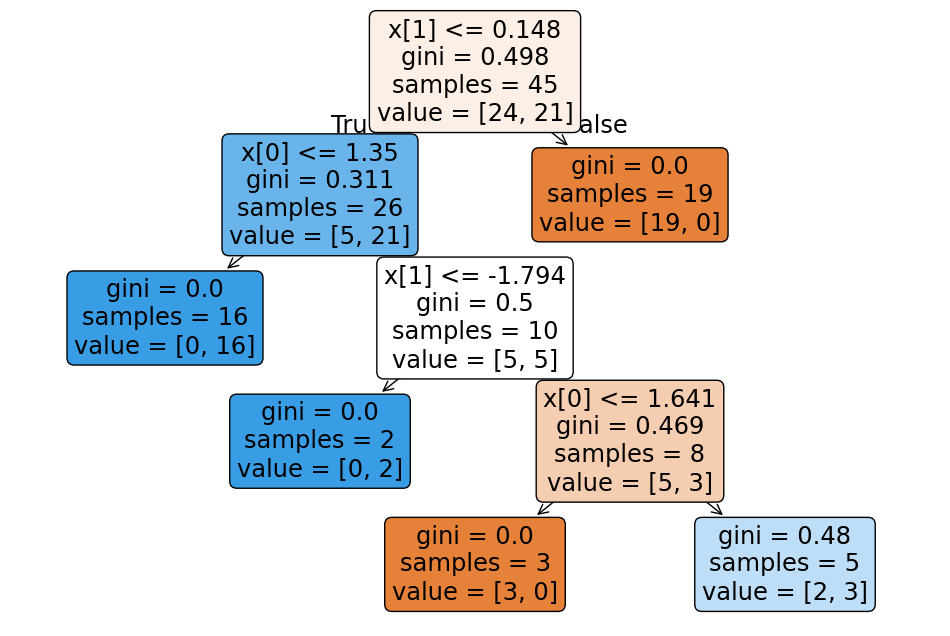

In [8]:
# Escoger el mejor alpha
mejor_alpha = ccp_alphas[2]

# Y entrenar el árbol con este alpha para llevar a cabo la poda
arbol_podado = DecisionTreeClassifier(random_state=42, ccp_alpha=mejor_alpha)
arbol_podado.fit(x_tr, y_tr)

# Graficar y almacenar el gráfico del árbol resultante
plt.figure(figsize=(12, 8))
plot_tree(arbol_podado, filled=True, rounded=True);

Y podemos comparar el tamaño del árbol original (antes de la poda) con el tamaño del árbol podado:

In [9]:
# Árbol original
arbol = DecisionTreeClassifier(max_depth=None, random_state=42)
arbol.fit(x_tr, y_tr)

# Comparar árbol original y árbol podado
print('Árbol original:')
print(f'  Profundidad: {arbol.get_depth()}')
print(f'  Número de hojas: {arbol.get_n_leaves()}')
print(f'Árbol podado (alpha={mejor_alpha}):')
print(f'  Profundidad: {arbol_podado.get_depth()}')
print(f'  Número de hojas: {arbol_podado.get_n_leaves()}')

Árbol original:
  Profundidad: 7
  Número de hojas: 8
Árbol podado (alpha=0.023703703703703703):
  Profundidad: 4
  Número de hojas: 5
